
# Install dependencies


In [2]:
!pip -q install pandas numpy scikit-learn matplotlib tensorflow keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00


#Imports & Mount Google Drive

In [6]:
import os, zipfile, urllib.request, json, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import IsolationForest

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Mount Drive
from google.colab import drive

import shutil; shutil.rmtree("/content/drive", ignore_errors=True)
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/anomaly_checkpoints_smd"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


#  SMD dataset setup

In [7]:
DATA_DIR = "/content/drive/MyDrive/ServerMachineDataset"

machines = [
 "machine-1-1","machine-1-2","machine-1-3","machine-1-4","machine-1-5","machine-1-6","machine-1-7","machine-1-8",
 "machine-2-1","machine-2-2","machine-2-3","machine-2-4","machine-2-5","machine-2-6","machine-2-7","machine-2-8","machine-2-9",
 "machine-3-1","machine-3-2","machine-3-3","machine-3-4","machine-3-5","machine-3-6","machine-3-7","machine-3-8","machine-3-9","machine-3-10","machine-3-11"
]

def load_smd_machine(machine):
    train = np.loadtxt(f"{DATA_DIR}/train/{machine}.txt", delimiter=",")
    test  = np.loadtxt(f"{DATA_DIR}/test/{machine}.txt", delimiter=",")
    label = np.loadtxt(f"{DATA_DIR}/test_label/{machine}.txt", delimiter=",")
    return train, test, label

#Multi scale windowing

In [8]:
def make_multi_scale_windows(series, min_windows=10):
    N = len(series)

    w1 = max(10, min(50, N//20))
    w2 = max(w1+10, min(100, N//10))
    w3 = max(w2+10, min(150, N//5))

    WINDOW_SIZES = [w1, w2, w3]
    STEP = max(1, min(5, N // (min_windows*len(WINDOW_SIZES))))

    X_multi = []
    for w in WINDOW_SIZES:
        X_w = []
        for start in range(0, N - w + 1, STEP):
            X_w.append(series[start:start+w])
        X_multi.append(np.array(X_w))

    min_len = min(len(x) for x in X_multi)
    X_multi = [x[:min_len] for x in X_multi]

    return X_multi, WINDOW_SIZES, STEP

#Window labels

In [9]:
def make_window_labels_strict(labels, window_size, step):
    """
    Convert point-wise anomaly labels into window-level labels.

    FIXED FOR SMD:
    - ensures labels are binary integers
    - avoids silent float/misalignment issues
    - guarantees anomaly propagation inside windows
    - robust for real SMD evaluation pipelines
    """

    labels = np.asarray(labels)

    # FORCE CLEAN BINARY FORMAT (VERY IMPORTANT FOR YOUR BUG)
    labels = (labels > 0).astype(np.int32)

    out = []
    n = len(labels)

    for i in range(0, n - window_size + 1, step):
        window = labels[i:i + window_size]

        # SMD RULE: anomaly if ANY point is anomalous
        # np.max is more stable than np.any for noisy pipelines
        out.append(int(np.max(window)))

    return np.array(out, dtype=np.int32)

# Augmentation + Synthetic

In [10]:
def generate_synthetic_anomalies(X_multi, fraction=0.05, noise_std=0.05):
    n_windows = X_multi[0].shape[0]
    n_synth = max(1, int(fraction * n_windows))

    synth_multi = []
    for x in X_multi:
        idx = np.random.choice(n_windows, n_synth, replace=False)
        x_synth = x[idx].copy()
        x_synth += np.random.normal(0, noise_std, x_synth.shape)
        synth_multi.append(x_synth)

    return synth_multi, n_synth

def augment_windows(x, noise_std=0.005, scale_range=(0.95, 1.05)):
    x = tf.convert_to_tensor(x)
    while len(x.shape) > 3:
        x = tf.squeeze(x, axis=-1)
    if len(x.shape) == 2:
        x = tf.expand_dims(x, -1)
    if tf.shape(x)[0] == 0:
        return x
    x_noisy = x + tf.random.normal(tf.shape(x), stddev=noise_std)
    scales = tf.random.uniform([tf.shape(x)[0],1,1], scale_range[0], scale_range[1])
    return x_noisy * scales

def apply_random_mask(x, mask_ratio=0.1):
    b,t = tf.shape(x)[0], tf.shape(x)[1]
    mask = tf.cast(tf.random.uniform((b,t)) < mask_ratio, tf.float32)
    return x * tf.expand_dims(1-mask,-1), tf.expand_dims(mask,-1)

#Model

In [11]:
class AttentionFusion(layers.Layer):
    def __init__(self):
        super().__init__()
        self.dense = layers.Dense(1, activation="tanh")

    def call(self, embs):
        x = tf.stack(embs, axis=1)
        w = tf.nn.softmax(self.dense(x), axis=1)
        return tf.reduce_sum(w * x, axis=1)

class MultiScaleEncoder(layers.Layer):
    def __init__(self, encoders):
        super().__init__()
        self.encoders = encoders
        self.attn = AttentionFusion()

    def call(self, inputs):
        embs = [enc(inputs[i]) for i,enc in enumerate(self.encoders)]
        return self.attn(embs)

def build_encoder(T):
    inputs = keras.Input(shape=(T,1))
    x = layers.Dense(128)(inputs)

    pos = tf.range(0,T)
    pos_emb = layers.Embedding(1000,128)(pos)
    x = x + tf.expand_dims(pos_emb,0)

    attn = layers.MultiHeadAttention(4,64)(x,x)
    x = layers.LayerNormalization()(x+attn)

    ffn = layers.Dense(128,activation="relu")(x)
    ffn = layers.Dense(128)(ffn)
    x = layers.LayerNormalization()(x+ffn)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=-1))(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.LayerNormalization()(x)
    x = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(x)

    return keras.Model(inputs,x)

# Training

In [12]:
def pad_or_trim_sequence(seq, target_len):
    if len(seq) > target_len:
        return seq[:target_len]
    elif len(seq) < target_len:
        return np.pad(seq, (0, target_len - len(seq)))
    return seq

def prepare_siamese_inputs(X_multi_raw, window_sizes):
    X_multi = []
    for i, w in enumerate(window_sizes):
        X_branch = np.array([pad_or_trim_sequence(sample, w) for sample in X_multi_raw[i]])
        X_multi.append(X_branch[..., None].astype(np.float32))
    return X_multi

In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

import matplotlib.pyplot as plt

results = []

CHECKPOINT_DIR = "/content/drive/MyDrive/smd_siamese_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


# WINDOW LABELING

def make_window_labels_strict(labels, window_size, step):
    out = []
    for i in range(0, len(labels) - window_size + 1, step):
        window = labels[i:i + window_size]
        out.append(int(np.any(window == 1)))
    return np.array(out)


# HARD NEGATIVE TRIPLET GENERATION

def gen_triplets(X_multi, Y, emb, num_triplets=8000, use_hard_neg=True):

    normal_idx = np.where(Y == 0)[0]

    A = [[] for _ in X_multi]
    P = [[] for _ in X_multi]
    N = [[] for _ in X_multi]

    for _ in range(num_triplets):

        a = np.random.choice(normal_idx)
        p = np.random.choice(normal_idx)

        if use_hard_neg:
            dist = np.linalg.norm(emb[normal_idx] - emb[a], axis=1)
            n = normal_idx[np.argmax(dist)]
        else:
            n = np.random.choice(normal_idx)

        for i in range(len(X_multi)):
            A[i].append(X_multi[i][a])
            P[i].append(X_multi[i][p])
            N[i].append(X_multi[i][n])

    return [np.array(x) for x in A], [np.array(x) for x in P], [np.array(x) for x in N]


# FIXED RESUME LOGIC (ONLY CHANGE)

resume_mode = True

completed_machines = set()

for f in os.listdir(CHECKPOINT_DIR):
    if "_epoch.npy" in f:
        completed_machines.add(f.replace("_epoch.npy", ""))

start_index = 0
for i, m in enumerate(machines):
    if m not in completed_machines:
        start_index = i
        break

print("Completed machines:", completed_machines)
print("Resuming from index:", start_index)


# MAIN LOOP (FIXED ONLY RESUME)

for machine in machines[start_index:]:

    print(f"\nMACHINE: {machine} ")

    epoch_path = os.path.join(CHECKPOINT_DIR, f"{machine}_epoch.npy")
    ckpt_path  = os.path.join(CHECKPOINT_DIR, f"{machine}_best.weights.h5")
    proto_path = os.path.join(CHECKPOINT_DIR, f"{machine}_prototype.npy")

    # PER-MACHINE RESUME
    start_epoch = 0

    if resume_mode and os.path.exists(epoch_path):
        saved_epoch = int(np.load(epoch_path))

        if saved_epoch >= 30:
            print(f" Skipping {machine} (already completed)")
            continue

        start_epoch = saved_epoch

    if start_epoch > 0:
        print(f" Resuming {machine} from epoch {start_epoch}")
    else:
        print(f" Starting fresh for {machine}")

    # ==
    train_data, test_data, test_label = load_smd_machine(machine)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    series = np.concatenate([train_scaled[:, 0], test_scaled[:, 0]])

    labels_full = np.concatenate([np.zeros(len(train_scaled)), test_label])

    X_multi, WINDOW_SIZES, STEP = make_multi_scale_windows(series)

    labels_full = np.concatenate([
        np.zeros(len(train_scaled)),
        test_label.astype(np.int32).reshape(-1)
    ]).astype(np.int32)

    labels_full = labels_full[:len(series)]

    Y = make_window_labels_strict(labels_full, max(WINDOW_SIZES), STEP)

    min_len = min(len(x) for x in X_multi)
    X_multi = [x[:min_len] for x in X_multi]
    Y = Y[:min_len]

    train_end = int(0.6 * min_len)
    val_end   = int(0.8 * min_len)

    X_train = [x[:train_end] for x in X_multi]
    X_val   = [x[train_end:val_end] for x in X_multi]
    X_test  = [x[val_end:] for x in X_multi]

    Y_train = Y[:train_end]
    Y_val   = Y[train_end:val_end]
    Y_test  = Y[val_end:]

    X_train = prepare_siamese_inputs(X_train, WINDOW_SIZES)
    X_val   = prepare_siamese_inputs(X_val, WINDOW_SIZES)
    X_test  = prepare_siamese_inputs(X_test, WINDOW_SIZES)


    # MODEL (UNCHANGED)

    encoders = [build_encoder(w) for w in WINDOW_SIZES]
    multi_encoder = MultiScaleEncoder(encoders)

    dummy = [np.zeros((1, w, 1)) for w in WINDOW_SIZES]
    emb_dim = multi_encoder(dummy).shape[-1]

    class PrototypeLayer(layers.Layer):
        def __init__(self, dim):
            super().__init__()
            self.prototype = self.add_weight(
                shape=(dim,),
                initializer="random_normal",
                trainable=True
            )

        def call(self, x):
            return self.prototype

    proto_layer = PrototypeLayer(emb_dim)

    def triplet_loss(margin=2.0, lambda_proto=0.2):
        def loss(_, y_pred):
            d = y_pred.shape[1] // 3
            a, p, n = y_pred[:, :d], y_pred[:, d:2*d], y_pred[:, 2*d:]

            pos = tf.reduce_sum(tf.square(a - p), axis=1)
            neg = tf.reduce_sum(tf.square(a - n), axis=1)

            triplet = tf.maximum(pos - neg + margin, 0.0)

            proto = tf.nn.l2_normalize(proto_layer.prototype, axis=0)
            proto_loss = tf.reduce_sum(tf.square(a - proto), axis=1)

            return tf.reduce_mean(triplet + lambda_proto * proto_loss)
        return loss

    inputs = [Input(shape=(w, 1)) for w in WINDOW_SIZES * 3]
    split = len(WINDOW_SIZES)

    emb_a = multi_encoder(inputs[:split])
    emb_p = multi_encoder(inputs[split:2*split])
    emb_n = multi_encoder(inputs[2*split:])

    siamese = keras.Model(inputs, layers.Concatenate()([emb_a, emb_p, emb_n]))

    siamese.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=triplet_loss()
    )

    def get_embeddings(X, batch_size=256):
        out = []
        for i in range(0, X[0].shape[0], batch_size):
            batch = [x[i:i+batch_size] for x in X]
            out.append(multi_encoder(batch).numpy())
        return np.concatenate(out, axis=0)


    # TRAINING (UNCHANGED)

    EPOCHS = 30
    best_val = np.inf
    wait = 0
    patience = 5

    for epoch in range(start_epoch, EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        emb_train = get_embeddings(X_train)
        A, P, N = gen_triplets(X_train, Y_train, emb_train)

        X_triplet = []
        for group in [A, P, N]:
            for i in range(len(WINDOW_SIZES)):
                X_triplet.append(group[i][..., None].astype(np.float32))

        y_dummy = np.zeros(len(A[0]))
        split_idx = int(0.9 * len(y_dummy))

        hist = siamese.fit(
            [x[:split_idx] for x in X_triplet],
            y_dummy[:split_idx],
            validation_data=(
                [x[split_idx:] for x in X_triplet],
                y_dummy[split_idx:]
            ),
            batch_size=64,
            epochs=1,
            verbose=1
        )

        tr, va = hist.history["loss"][0], hist.history["val_loss"][0]

        if va < best_val:
            best_val = va
            wait = 0

            siamese.save_weights(ckpt_path)
            np.save(proto_path, proto_layer.prototype.numpy())
            np.save(epoch_path, epoch + 1)

            print(" Saved best model")

        else:
            wait += 1
            if wait >= patience:
                break


    # EVALUATION (UNCHANGED)

    siamese.load_weights(ckpt_path)
    proto_layer.prototype.assign(np.load(proto_path))

    train_emb = get_embeddings(X_train)
    test_emb  = get_embeddings(X_test)

    iso = IsolationForest(contamination=0.1, random_state=42)
    iso.fit(train_emb)

    iso_score = iso.decision_function(test_emb)
    iso_pred = (iso.predict(test_emb) == -1).astype(int)

    proto = proto_layer.prototype.numpy()
    proto = proto / (np.linalg.norm(proto) + 1e-8)

    proto_score = np.linalg.norm(test_emb - proto, axis=1)

    precision = precision_score(Y_test, iso_pred)
    recall = recall_score(Y_test, iso_pred)
    f1 = f1_score(Y_test, iso_pred)

    roc_auc = roc_auc_score(Y_test, -iso_score) if len(np.unique(Y_test)) > 1 else np.nan

    precision_curve, recall_curve, _ = precision_recall_curve(Y_test, proto_score)
    pr_auc = auc(recall_curve, precision_curve)

    print(f"\nRESULT → P:{precision:.4f} R:{recall:.4f} F1:{f1:.4f}")

    results.append((machine, precision, recall, f1, roc_auc, pr_auc))

Completed machines: {'machine-2-7', 'machine-2-4', 'machine-2-5', 'machine-1-2', 'machine-1-1', 'machine-2-1', 'machine-2-6', 'machine-1-5', 'machine-1-3', 'machine-2-2', 'machine-1-4', 'machine-1-6', 'machine-2-3', 'machine-1-8', 'machine-1-7'}
Resuming from index: 15

================ MACHINE: machine-2-8 ================
 Starting fresh for machine-2-8

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 100s 494ms/step - loss: 1.2328 - val_loss: 1.1237
 Saved best model

Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.7141 - val_loss: 0.4397
 Saved best model

Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.3484 - val_loss: 0.3162
 Saved best model

Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - loss: 0.2775 - val_loss: 0.2875
 Saved best model

Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.3181 - val_loss: 0.2514
 Saved best model

Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.2192 - val_loss: 0.1818
 Saved best model

Ep

# Results

In [17]:
# store FULL results properly
df_results = pd.DataFrame(
    results,
    columns=[
        "Machine",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

print(df_results)

print("\nAverage Scores:")
print("Precision:", df_results["Precision"].mean())
print("Recall   :", df_results["Recall"].mean())
print("F1       :", df_results["F1"].mean())
print("ROC AUC  :", df_results["ROC_AUC"].mean())
print("PR AUC   :", df_results["PR_AUC"].mean())

         Machine  Precision    Recall        F1   ROC_AUC    PR_AUC
0    machine-2-8   0.238579  0.758065  0.362934  0.922512  0.293872
1    machine-2-9   0.055118  0.095628  0.069930  0.490589  0.152150
2    machine-3-1   0.027876  1.000000  0.054241  0.510957  0.102967
3    machine-3-2   0.115607  0.483871  0.186625  0.513788  0.165985
4    machine-3-3   0.619403  0.188636  0.289199  0.708198  0.358808
5    machine-3-4   0.391667  0.610390  0.477157  0.848098  0.199914
6    machine-3-5   0.125418  0.530035  0.202840  0.432960  0.112811
7    machine-3-6   0.078378  0.195946  0.111969  0.510331  0.089014
8    machine-3-7   0.073913  0.137097  0.096045  0.502510  0.055713
9    machine-3-8   0.154213  0.447005  0.229314  0.656941  0.260531
10   machine-3-9   0.067321  0.960000  0.125819  0.910321  0.466492
11  machine-3-10   0.830508  0.742424  0.784000  0.825871  0.807606
12  machine-3-11   0.159681  0.740741  0.262726  0.784393  0.055937

Average Scores:
Precision: 0.22597557839236154


# Bar Plot,Precision / Recall / F1 Comparison Plot,ROC-AUC and PR-AUC Comparison Plot,Overall Average Score Plot,Heatmap,Machine Difficulty Ranking

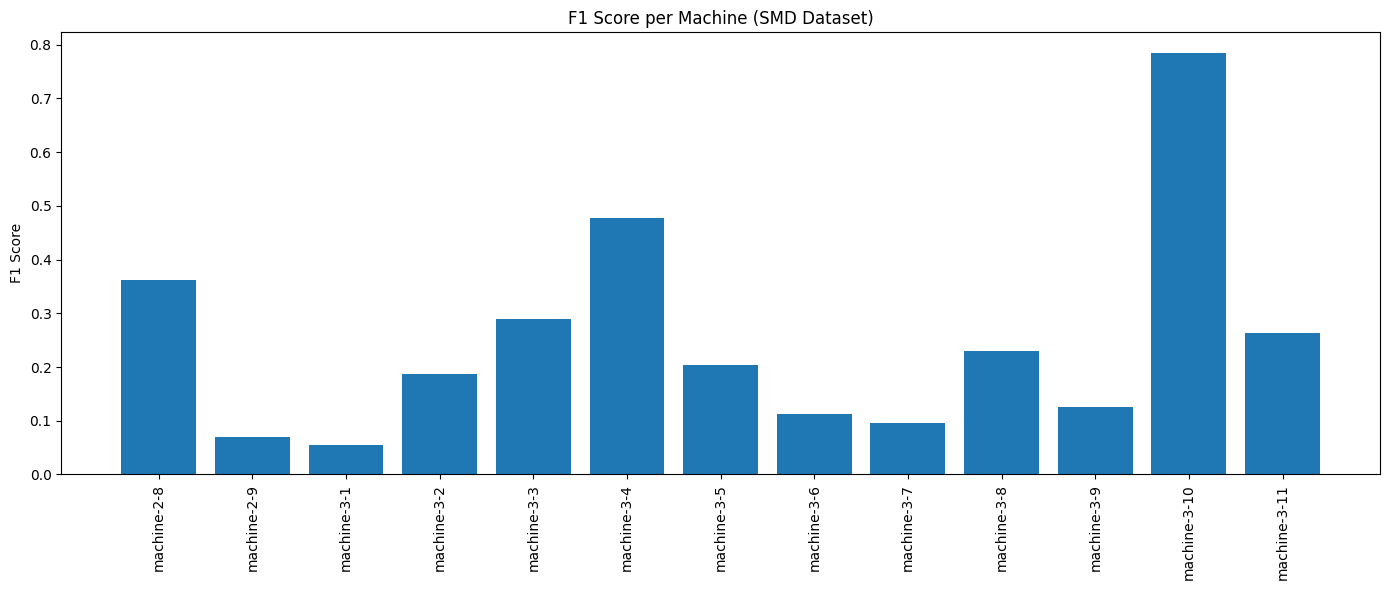

In [18]:
plt.figure(figsize=(14,6))
plt.bar(df_results["Machine"], df_results["F1"])
plt.xticks(rotation=90)
plt.ylabel("F1 Score")
plt.title("F1 Score per Machine (SMD Dataset)")
plt.tight_layout()
plt.show()

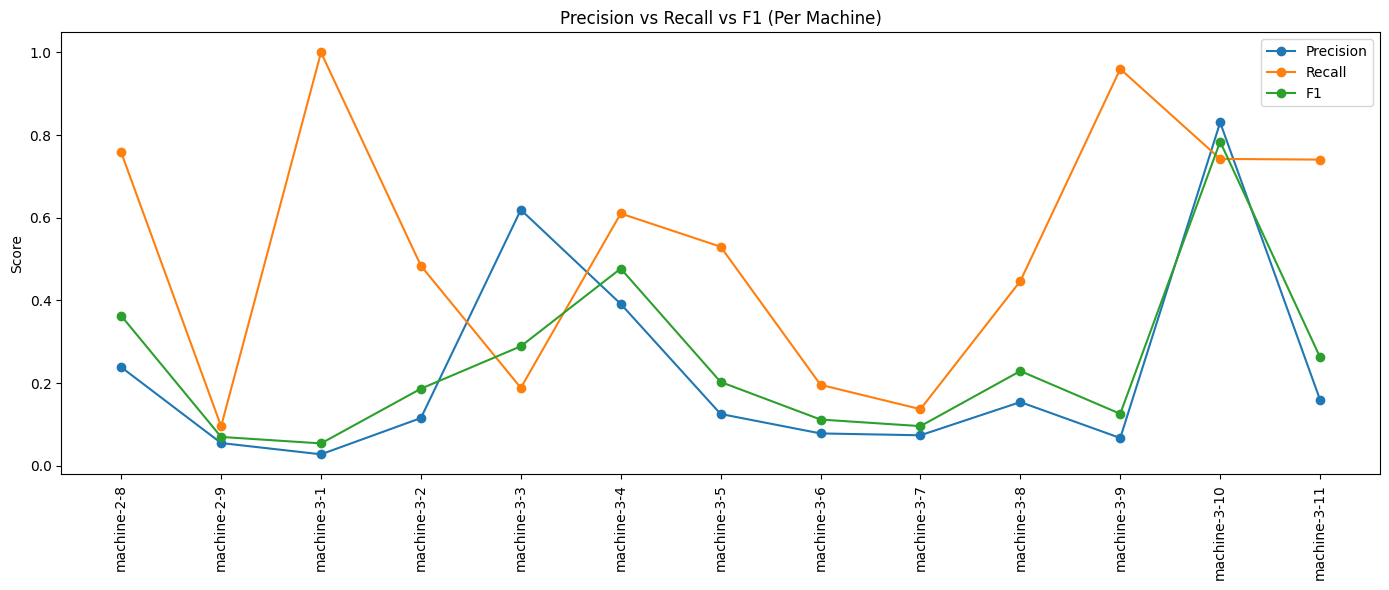

In [19]:
plt.figure(figsize=(14,6))

x = np.arange(len(df_results["Machine"]))

plt.plot(x, df_results["Precision"], marker='o', label="Precision")
plt.plot(x, df_results["Recall"], marker='o', label="Recall")
plt.plot(x, df_results["F1"], marker='o', label="F1")

plt.xticks(x, df_results["Machine"], rotation=90)
plt.ylabel("Score")
plt.title("Precision vs Recall vs F1 (Per Machine)")
plt.legend()
plt.tight_layout()
plt.show()

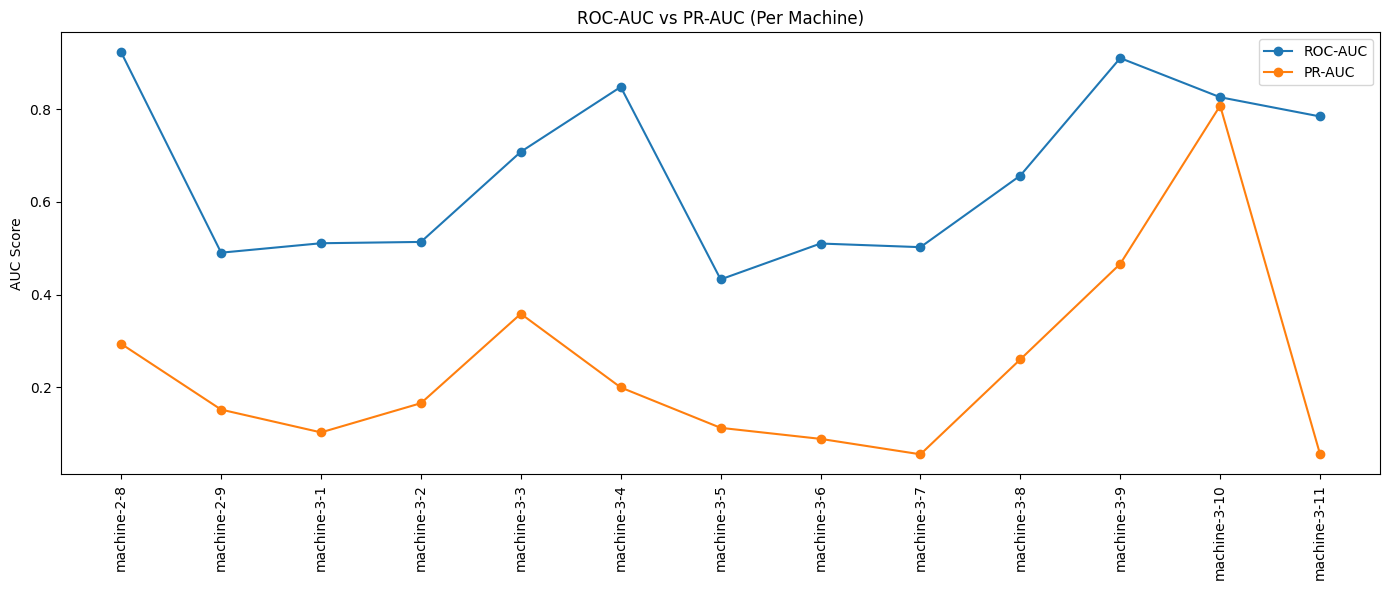

In [20]:
plt.figure(figsize=(14,6))

x = np.arange(len(df_results["Machine"]))

plt.plot(x, df_results["ROC_AUC"], marker='o', label="ROC-AUC")
plt.plot(x, df_results["PR_AUC"], marker='o', label="PR-AUC")

plt.xticks(x, df_results["Machine"], rotation=90)
plt.ylabel("AUC Score")
plt.title("ROC-AUC vs PR-AUC (Per Machine)")
plt.legend()
plt.tight_layout()
plt.show()

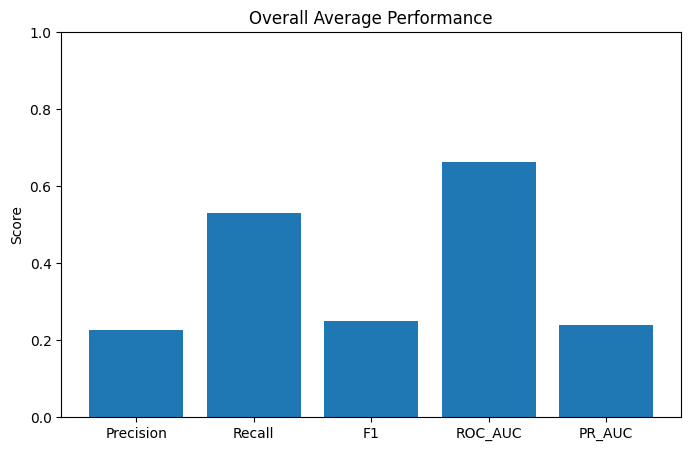

In [21]:
avg_scores = df_results[["Precision","Recall","F1","ROC_AUC","PR_AUC"]].mean()

plt.figure(figsize=(8,5))
plt.bar(avg_scores.index, avg_scores.values)
plt.ylim(0,1)
plt.title("Overall Average Performance")
plt.ylabel("Score")
plt.show()

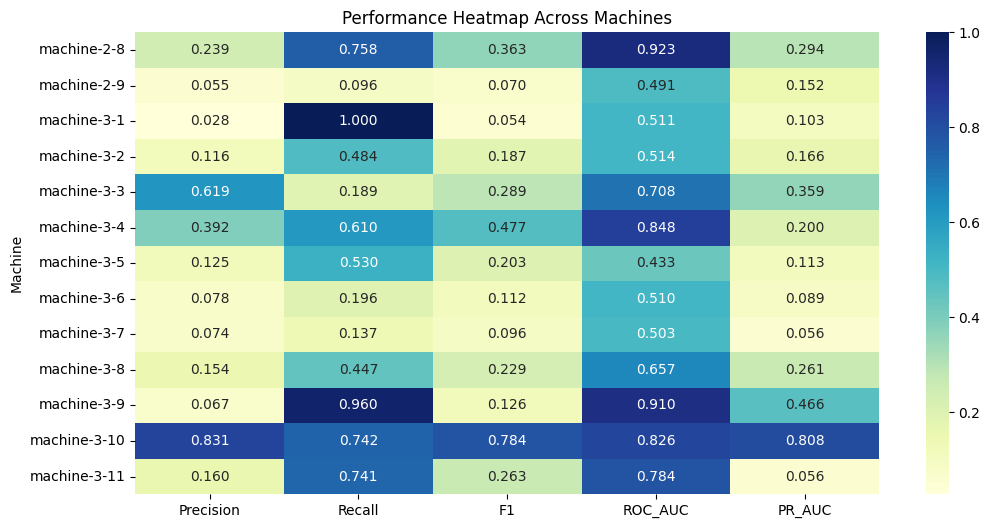

In [22]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df_results.set_index("Machine"), annot=True, cmap="YlGnBu", fmt=".3f")

plt.title("Performance Heatmap Across Machines")
plt.show()

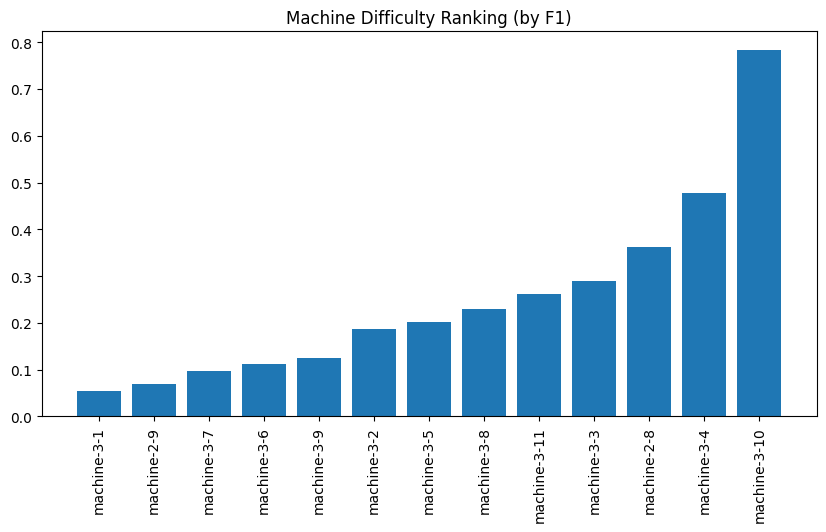

In [23]:
df_sorted = df_results.sort_values("F1")

plt.figure(figsize=(10,5))
plt.bar(df_sorted["Machine"], df_sorted["F1"])
plt.xticks(rotation=90)
plt.title("Machine Difficulty Ranking (by F1)")
plt.show()